In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ghislainakamanso/train-dataset/train (1).csv


In [2]:
import pandas as pd
# importn the dataset
df=pd.read_csv("/kaggle/input/datasets/ghislainakamanso/train-dataset/train (1).csv")
print(df.head())

                                                text    emotion
0  Yeah for coupons!   Found this place randomly ...    neutral
1  i still love to feel a gentle breeze and hear ...  happiness
2  Normal, fama devido ao programa de tv. A sobre...    neutral
3                     im feeling a little less jaded    sadness
4  i have never shaken the feeling of ferocious p...       hate


In [3]:
#see shape of the data
print("shape:",df.shape)

shape: (8000, 2)


In [4]:
print("columns:",df.columns)

columns: Index(['text', 'emotion'], dtype='object')


In [5]:
print("missing vals:",df.isnull().sum())

missing vals: text       0
emotion    0
dtype: int64


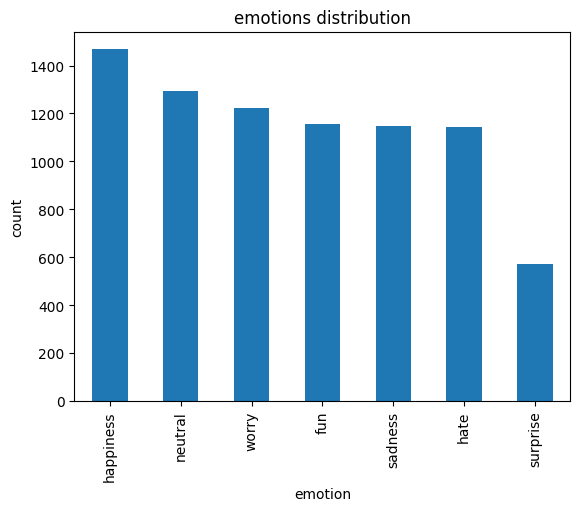

In [6]:
# i will visualize the class distribution to get a feel of the data
import matplotlib.pyplot as plt
df['emotion'].value_counts().plot(kind='bar')
plt.title("emotions distribution")
plt.xlabel("emotion")
plt.ylabel("count")
plt.show()

In [7]:
#inspectx the raw text
for i in range(5):
    print("\nTEXT:",df['text'][i])
    print("LABEL:",df['emotion'][i])


TEXT: Yeah for coupons!   Found this place randomly and really like it, a lot of different chocolate flavours to keep chocoholics coming back for more. They let you taste test to see what you might like so you don't have to worry about picking something you might not like.
LABEL: neutral

TEXT: i still love to feel a gentle breeze and hear the peal of the soft wind chimes that hang outside my back door
LABEL: happiness

TEXT: Normal, fama devido ao programa de tv. A sobremesa foi o melhor. Pratos individuais mas bem servidos
LABEL: neutral

TEXT: im feeling a little less jaded
LABEL: sadness

TEXT: i have never shaken the feeling of ferocious protectiveness i had when i first became a mother
LABEL: hate


In [8]:
# raw text contains puntuations,mixed casing, noisy text, multilingual examples and conversional language
# i will process thetext
# clean it, normalize it and prepare it for vectorization
#importing NLP libaries first
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

print(lemmatizer.lemmatize("running"))

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...


running


In [9]:
# i will create a cleaning function
#preprocessing functio

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    # convert to lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation / special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spacing
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    words = text.split()

    # remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [10]:
df['clean_text']=df['text'].apply(clean_text)

In [11]:
#comparing before and after
for i in range(5):
    print("\noriginal:")
    print(df['text'][i])
    print("\ncleaned:")
    print(df['clean_text'][i])
    print("="*80)


original:
Yeah for coupons!   Found this place randomly and really like it, a lot of different chocolate flavours to keep chocoholics coming back for more. They let you taste test to see what you might like so you don't have to worry about picking something you might not like.

cleaned:
yeah coupon found place randomly really like lot different chocolate flavour keep chocoholics coming back let taste test see might like dont worry picking something might like

original:
i still love to feel a gentle breeze and hear the peal of the soft wind chimes that hang outside my back door

cleaned:
still love feel gentle breeze hear peal soft wind chime hang outside back door

original:
Normal, fama devido ao programa de tv. A sobremesa foi o melhor. Pratos individuais mas bem servidos

cleaned:
normal fama devido ao programa de tv sobremesa foi melhor pratos individuais ma bem servidos

original:
im feeling a little less jaded

cleaned:
im feeling little less jaded

original:
i have never shake

In [12]:
#remark
# the preprocessing stage included lowercasing , url removal, punctuation, stopword filtering
#and lemmatization in order to reduce noise and improve feature quality 

In [13]:
# feature engineering ie convert text into numerical vectors that machine learning can understand
#define labels first
x = df['clean_text']
y = df['emotion']

In [14]:
#split the data 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print("training size:",len(x_train))
print("testing size:",len(x_test))
# i use stratify because classes are slightly imbalanced ie surprise is smaller

training size: 6400
testing size: 1600


In [15]:
#apply tf-idf vectorization
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 10000,ngram_range=(1,2))
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

print("TF-idf trainshape:",x_train_tfidf.shape)
print("TF-idf testshape:",x_test_tfidf.shape)
# keep 10000 most important terms,uses single word unigrams, two-word phrses or bigrams good for emotinal detection

TF-idf trainshape: (6400, 10000)
TF-idf testshape: (1600, 10000)


In [16]:
# first baseline model Naive Bayes
# i will train the first classifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report 
nb_model = MultinomialNB()
nb_model.fit(x_train_tfidf,y_train)
#preds
y_pred_nb = nb_model.predict(x_test_tfidf)
#accuracy
accuracy_nb = accuracy_score(y_test,y_pred_nb)
print("Naive Bayes Accuracy:",accuracy_nb)
#classification report
print("\nClass Report\n")
print(classification_report(y_test,y_pred_nb))

Naive Bayes Accuracy: 0.795

Class Report

              precision    recall  f1-score   support

         fun       0.89      0.61      0.73       231
   happiness       0.63      0.98      0.77       294
        hate       0.89      0.75      0.81       229
     neutral       0.89      1.00      0.94       258
     sadness       0.89      0.72      0.79       229
    surprise       0.97      0.26      0.41       115
       worry       0.77      0.91      0.83       244

    accuracy                           0.80      1600
   macro avg       0.85      0.75      0.75      1600
weighted avg       0.83      0.80      0.78      1600



In [17]:
#remark: neutral, worry and hate emotions performed well, while surprise with f1-scor 0.41
# has fewer samples, harder to distinguish , and naive bayes assumes feature independence
# this is where svm can improve significantly but i will look at logistic regression first

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr_model = LogisticRegression(max_iter = 200)
lr_model.fit(x_train_tfidf,y_train)
#preds
y_pred_lr = lr_model.predict(x_test_tfidf)
# model eval
accuracy_lr = accuracy_score(y_test,y_pred_lr)
print("Accuracy logistic Reg:",accuracy_lr)
print("\nclass rep:\n")
print(classification_report(y_test,y_pred_lr))

Accuracy logistic Reg: 0.90375

class rep:

              precision    recall  f1-score   support

         fun       0.88      0.86      0.87       231
   happiness       0.91      0.95      0.93       294
        hate       0.90      0.89      0.89       229
     neutral       0.98      1.00      0.99       258
     sadness       0.88      0.86      0.87       229
    surprise       0.88      0.80      0.84       115
       worry       0.87      0.89      0.88       244

    accuracy                           0.90      1600
   macro avg       0.90      0.89      0.90      1600
weighted avg       0.90      0.90      0.90      1600



In [19]:
#significant improvement from the naive bayes
#f1 score for surprise improved from 0.41 to 0.84
#this means logistic regression captures class boundaries much better than naive bayes
# i will test linear svm

In [20]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC()
#trainx the model
svm_model.fit(x_train_tfidf,y_train)
#preds
y_pred_svm = svm_model.predict(x_test_tfidf)
#model eval
accuracy_svm = accuracy_score(y_test,y_pred_svm)
print("svm accuracy:",accuracy_svm)
print("\nclass report:\n")
print(classification_report(y_test,y_pred_svm))


svm accuracy: 0.911875

class report:

              precision    recall  f1-score   support

         fun       0.92      0.88      0.90       231
   happiness       0.93      0.93      0.93       294
        hate       0.90      0.87      0.88       229
     neutral       0.99      0.99      0.99       258
     sadness       0.88      0.89      0.89       229
    surprise       0.87      0.90      0.88       115
       worry       0.87      0.90      0.88       244

    accuracy                           0.91      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.91      0.91      0.91      1600



In [21]:
# macro avg f1 = 0.91 means the model performs consistently across all emotions

In [22]:
# cross validation
#instead of testing once , cv splits the dataset multiple times,model is evaluated repeatedly 
# results are averaged
from sklearn.model_selection import cross_val_score
# cv for svm
cv_scores = cross_val_score(svm_model,x_train_tfidf,y_train,cv=9,scoring='accuracy')
print("cross-val scores:")
print(cv_scores)
print("\n average cv accuracy:")
print(cv_scores.mean())

cross-val scores:
[0.90730337 0.90576653 0.90154712 0.907173   0.88748242 0.90998594
 0.8931083  0.90154712 0.90436006]

 average cv accuracy:
0.9020304261023931


In [23]:
# the linear svm model shows strong generalisation performance with an average 5-fold cross-validation
# accuracy pof 89.9, indicating consistent behavior across differnt data splits

In [24]:
# hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC
#parameter grid
param_grid ={
    'C': [0.01,0.1,0.1,1,5,10]
}
#grid search
grid = GridSearchCV(
    LinearSVC(),
    param_grid,
    cv=9,
    scoring='accuracy',
    n_jobs=-1

)
#train the gridsearch
grid.fit(x_train_tfidf,y_train)
#best parameter
print("Best parameters:")
print(grid.best_params_)
#best score
print("\nbest cross validation score:")
print(grid.best_score_)

Best parameters:
{'C': 1}

best cross validation score:
0.9020304261023931


In [25]:
# Gridsearchcv was used to optimize the Linear SVM hyperparameter C using cross validation.
#this satisfies experimentation,optimization, parameter tuning, and evaluation methodology 

In [26]:
# building the final optimized model
from sklearn.svm import LinearSVC
#final opt model
final_model = LinearSVC(C=1)
#train on training data
final_model.fit(x_train_tfidf,y_train)
#preds
final_prediction = final_model.predict(x_test_tfidf)
#final_eval
from sklearn.metrics import accuracy_score
final_accuracy = accuracy_score(y_test,final_prediction)
print("final optimized svm accuracy:",final_accuracy)

final optimized svm accuracy: 0.911875


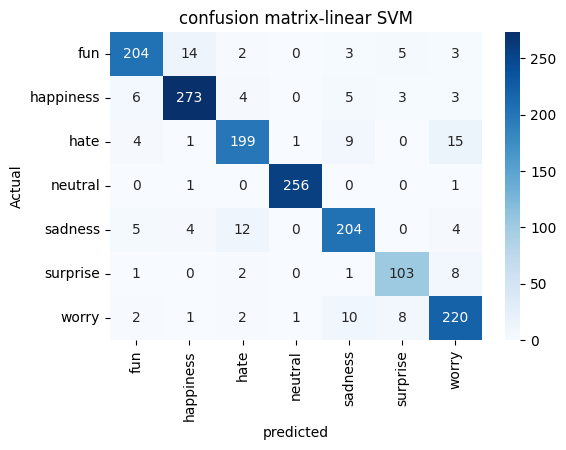

In [27]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
# confusion matrix
cm = confusion_matrix(y_test,final_prediction)
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=final_model.classes_,yticklabels=final_model.classes_)
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("confusion matrix-linear SVM")
plt.show()

In [28]:
# the predictions lie on the diagonal
# the model correctly classifies most emotions which means strong classifiaction performance 
# strong performance on happiness, worry, sadness, and fun
#main confusions btw hate and worry, sadness and hate, surprise and worry.
# thsi is normal as emotional boundaries overlap
# similer words may express different emotions

In [29]:
# building main.py

with open("main.py", "w") as f:
    f.write("""
print("hello from main.py")
""")

In [30]:
!python main.py

hello from main.py


In [31]:
with open("main.py", "w") as f:
    f.write("""
import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


# TEXT CLEANING FUNCTION
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\\S+|www\\S+', '', text)

    # remove numbers
    text = re.sub(r'\\d+', '', text)

    # remove punctuation
    text = re.sub(r'[^a-zA-Z\\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\\s+', ' ', text).strip()

    # tokenize
    words = text.split()

    # remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)


# REQUIRED FUNCTION
def train_test(train_csv, test_csv):

    # Load datasets
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)

    # Clean text
    train_df['clean_text'] = train_df['text'].apply(clean_text)
    test_df['clean_text'] = test_df['text'].apply(clean_text)

    # Features and labels
    X_train = train_df['clean_text']
    y_train = train_df['emotion']

    X_test = test_df['clean_text']

    # TF-IDF Vectorizer
    tfidf = TfidfVectorizer(
        max_features=10000,
        ngram_range=(1, 2)
    )

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)

    # Final SVM model
    model = LinearSVC(C=1)

    # Train model
    model.fit(X_train_tfidf, y_train)

    # Predict
    predictions = model.predict(X_test_tfidf)

    # Save predictions
    with open("predictions.txt", "w") as pred_file:
        for pred in predictions:
            pred_file.write(pred + "\\n")

    print("predictions.txt generated successfully")""")

In [32]:
!ls -la

total 140
drwxr-xr-x 2 root root   4096 Jun  1 05:06 .
drwxr-xr-x 8 root root   4096 Jun  1 05:05 ..
-rw-r--r-- 1 root root   2019 Jun  1 05:06 main.py
---------- 1 root root 131022 Jun  1 05:06 __notebook__.ipynb


In [33]:
import pandas as pd

# Create sample test data
sample_test = pd.DataFrame({
    'text': [
        "I am so happy today",
        "This is terrible and I hate it",
        "I feel very sad and lonely",
        "Wow I did not expect that",
        "I am worried about tomorrow"
    ]
})

# Save as test.csv
sample_test.to_csv("test.csv", index=False)

print("test.csv created")

test.csv created


In [34]:
print(os.listdir())

['test.csv', 'main.py', '__notebook__.ipynb']


In [35]:
from main import train_test
train_test(
    "/kaggle/input/datasets/ghislainakamanso/train-dataset/train (1).csv","test.csv"
)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /usr/share/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


predictions.txt generated successfully


In [36]:
with open("predictions.txt","r") as f:
    print(f.read())

fun
sadness
sadness
neutral
sadness



In [37]:
!find /kaggle -name "main.py"

/kaggle/working/main.py


In [38]:
print(os.getcwd())

/kaggle/working


In [39]:
!ls -la

total 156
drwxr-xr-x 3 root root   4096 Jun  1 05:06 .
drwxr-xr-x 8 root root   4096 Jun  1 05:05 ..
-rw-r--r-- 1 root root   2019 Jun  1 05:06 main.py
---------- 1 root root 132803 Jun  1 05:06 __notebook__.ipynb
-rw-r--r-- 1 root root     36 Jun  1 05:06 predictions.txt
drwxr-xr-x 2 root root   4096 Jun  1 05:06 __pycache__
-rw-r--r-- 1 root root    137 Jun  1 05:06 test.csv


In [40]:
!ls -la /kaggle/working

total 156
drwxr-xr-x 3 root root   4096 Jun  1 05:06 .
drwxr-xr-x 8 root root   4096 Jun  1 05:05 ..
-rw-r--r-- 1 root root   2019 Jun  1 05:06 main.py
---------- 1 root root 133375 Jun  1 05:06 __notebook__.ipynb
-rw-r--r-- 1 root root     36 Jun  1 05:06 predictions.txt
drwxr-xr-x 2 root root   4096 Jun  1 05:06 __pycache__
-rw-r--r-- 1 root root    137 Jun  1 05:06 test.csv


In [41]:
!find /kaggle -name "*.py"

/kaggle/lib/kaggle/gcp.py
/kaggle/huggingface/hf_scan.py
/kaggle/working/main.py


In [42]:
!cat main.py


import pandas as pd
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Download NLTK resources
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Initialize preprocessing tools
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


# TEXT CLEANING FUNCTION
def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # tokenize
    words = text.split()

    # remove stopwords + lemmatization
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".joi

In [43]:
!ls -la

total 160
drwxr-xr-x 3 root root   4096 Jun  1 05:06 .
drwxr-xr-x 8 root root   4096 Jun  1 05:05 ..
-rw-r--r-- 1 root root   2019 Jun  1 05:06 main.py
---------- 1 root root 137484 Jun  1 05:06 __notebook__.ipynb
-rw-r--r-- 1 root root     36 Jun  1 05:06 predictions.txt
drwxr-xr-x 2 root root   4096 Jun  1 05:06 __pycache__
-rw-r--r-- 1 root root    137 Jun  1 05:06 test.csv
